In [1]:
import sys, os
# --- project bootstrap ---------------------------------------------------
# This notebook lives under notebooks/post_training/, but it imports the my_image_jepa
# modules (dataset, model, ...) and reads paths relative to the my_image_jepa root
# (./data, ./checkpoints, cfgs/). Walk up to that root (the dir holding main.py + cfgs/)
# and make it both the working directory and an import root, so it runs from anywhere.
from pathlib import Path

ROOT = Path.cwd()
while not ((ROOT / "main.py").exists() and (ROOT / "cfgs").is_dir()) and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"project root: {ROOT}")

project root: /Users/hawardizayee/Desktop/AMI/eb_jepa/examples/my_image_jepa


In [2]:
import torch
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# trained image-JEPA checkpoint
artifact_dir = '/Users/hawardizayee/Desktop/AMI/eb_jepa/examples/my_image_jepa/artifacts/image_jepa_checkpoint:v0'
ckpt = torch.load(f"{artifact_dir}/latest.pth.tar", map_location="cpu")

In [3]:
from model import ResNet18, ImageSSL

# rebuild the encoder and load the trained weights
backbone = ResNet18()
model = ImageSSL(backbone=backbone, features_dim=backbone.features_dim)
model.load_state_dict(ckpt["model_state_dict"])

<All keys matched successfully>

In [4]:
import sys
from pathlib import Path

# class_prototypes.py lives next to this notebook. cwd is the my_image_jepa root (set
# by the bootstrap cell), so point at notebooks/post_training and add it to the path.
sys.path.insert(0, str(Path.cwd() / "notebooks" / "post_training"))
from class_prototypes import compute_class_centroids

# per-class prototype: mean 512-d backbone feature over all images of each class.
# see class_prototypes.compute_class_centroids for the full rationale.
centroids = compute_class_centroids(model)

device: mps


images per class: {'airplane': 5000, 'automobile': 5000, 'bird': 5000, 'cat': 5000, 'deer': 5000, 'dog': 5000, 'frog': 5000, 'horse': 5000, 'ship': 5000, 'truck': 5000}
centroid matrix: (10, 512)


### what is a `centroid` ? 

we summarize each class by one representative point: the mean (also called the centroid or prototype). <br>
Averaging over all 5000 frog images cancels out the per-image accidents — <br>
this frog's pose, that frog's background, lighting — and keeps what's common to frogs: the feature dimensions that consistently light up for the class. What survives the averaging is "frog-ness."

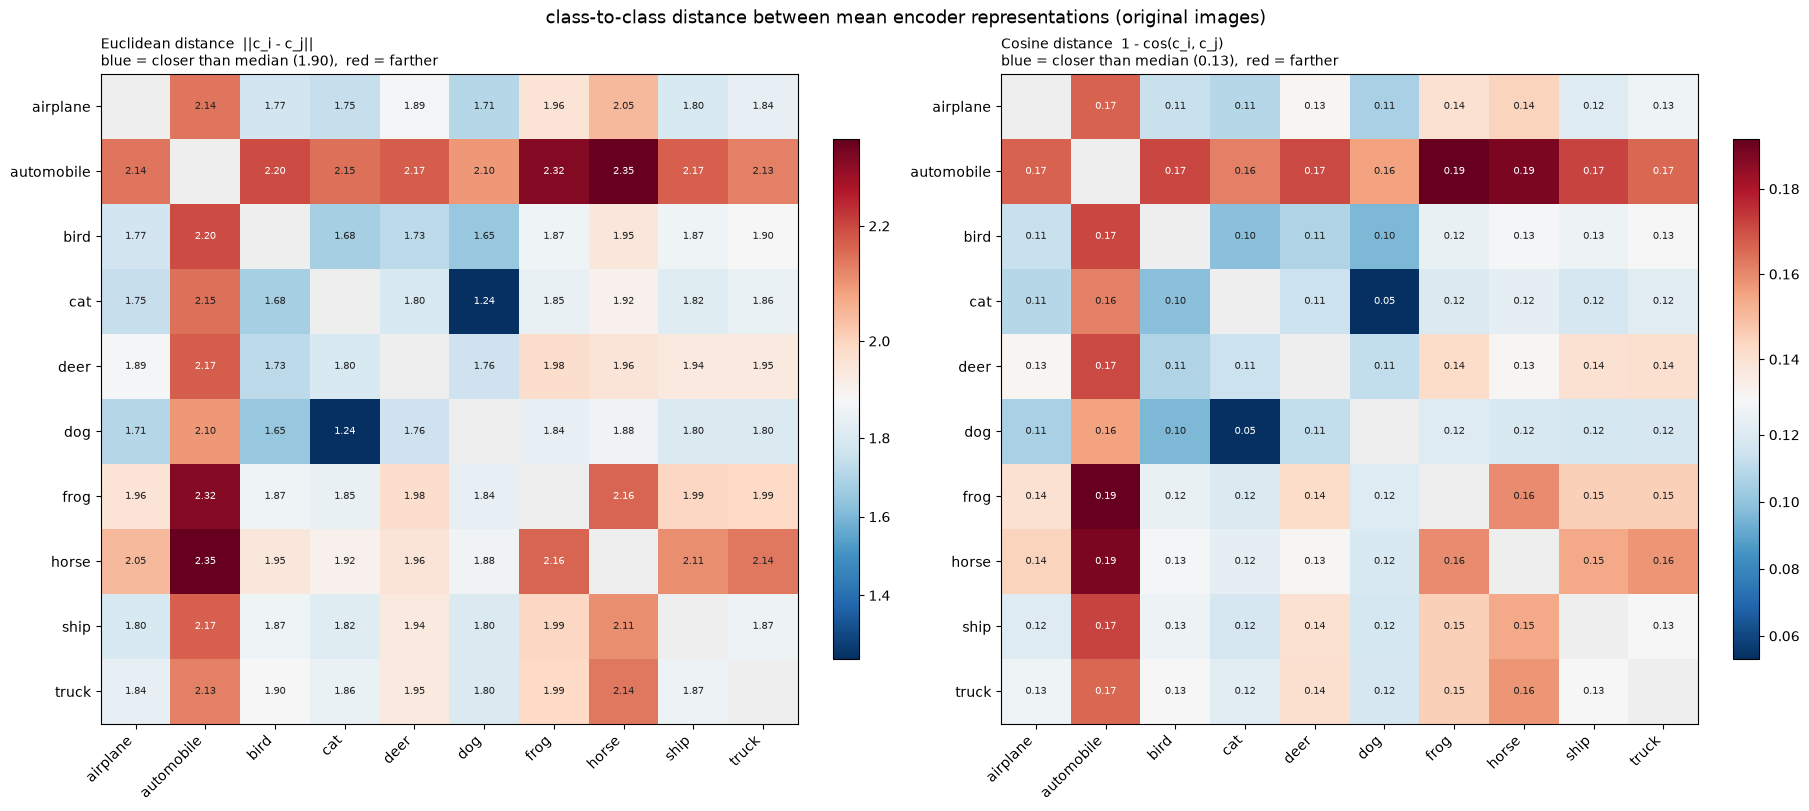


--- Euclidean ---
d(frog, horse)       = 2.164
d(frog, car)         = 2.316
  frog closer to horse than to car?  True   (gap +0.152)
d(frog, horse)       = 2.164   vs   d(car, boat) = 2.170   (|diff| 0.006)

--- Cosine ---
d(frog, horse)       = 0.159
d(frog, car)         = 0.192
  frog closer to horse than to car?  True   (gap +0.032)
d(frog, horse)       = 0.159   vs   d(car, boat) = 0.172   (|diff| 0.012)


In [5]:
from class_prototypes import plot_class_distance_matrices

# class-to-class distance (Euclidean & cosine) between the prototypes, plus a few
# specific comparisons. see class_prototypes.plot_class_distance_matrices for details.
euc, cos = plot_class_distance_matrices(centroids)

# K-Means Clustering

In [6]:
# extract the encoder features we want to cluster.
# same as the centroid code, but here we KEEP every image's feature (no per-class averaging):
# each image -> one 512-d backbone feature. we also keep the true label just to score
# the clustering afterwards (k-means itself never sees the labels).
import numpy as np
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from dataset import get_val_transforms
from class_prototypes import CIFAR10_CLASSES

device = "mps" if torch.backends.mps.is_available() else "cpu"

ds = CIFAR10(root="./data", train=False, download=False, transform=get_val_transforms())
loader = DataLoader(ds, batch_size=256, shuffle=False, num_workers=2)

feats, labels = [], []
model.eval().to(device)
with torch.no_grad():
    for x, y in loader:
        f, _ = model(x.to(device))      # [B, 512] backbone features (encoder output)
        feats.append(f.cpu().numpy())
        labels.append(y.numpy())
model.to("cpu")

X = np.concatenate(feats)               # [N, 512]
y_true = np.concatenate(labels)         # [N]
print("features:", X.shape, " labels:", y_true.shape)

features: (10000, 512)  labels: (10000,)


In [7]:
# fit k-means with k=10 (one cluster per CIFAR-10 class, unsupervised).
# k-means groups the 512-d features into 10 blobs by pure geometry, no labels involved.
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, n_init=10, random_state=0)
cluster_id = kmeans.fit_predict(X)      # [N] cluster assignment 0..9 per image

print("cluster sizes:", np.bincount(cluster_id))
print("inertia (sum of squared dists to nearest centroid):", f"{kmeans.inertia_:.1f}")

cluster sizes: [ 972  744  268  239 3431 1581  392  855  371 1147]
inertia (sum of squared dists to nearest centroid): 131113.7


In [8]:
# per-CLUSTER purity: label each cluster by its majority true class, then measure what
# fraction of the cluster is that class. NOTE this is a purity summary, not a classifier:
# each cluster votes independently, so two clusters can land on the SAME class (expected!)
# and some classes may get no cluster at all. the honest class-vs-class views are below.
from scipy.stats import mode

cluster_to_class = {}
for c in range(10):
    m = cluster_id == c
    cluster_to_class[c] = int(mode(y_true[m], keepdims=False).mode)   # dominant class in cluster c

for c in range(10):
    m = cluster_id == c
    frac = (y_true[m] == cluster_to_class[c]).mean()
    print(f"cluster {c}: size {m.sum():5d}  ->  {CIFAR10_CLASSES[cluster_to_class[c]]:<11} ({frac:.0%} pure)")

weighted_purity = np.mean([(y_true[cluster_id == c] == cluster_to_class[c]).mean()
                           for c in cluster_id])
print(f"\noverall purity (each image scored by its cluster's majority class): {weighted_purity:.3f}")

cluster 0: size   972  ->  truck       (95% pure)
cluster 1: size   744  ->  frog        (95% pure)
cluster 2: size   268  ->  horse       (99% pure)
cluster 3: size   239  ->  bird        (100% pure)
cluster 4: size  3431  ->  cat         (28% pure)
cluster 5: size  1581  ->  ship        (61% pure)
cluster 6: size   392  ->  airplane    (90% pure)
cluster 7: size   855  ->  automobile  (99% pure)
cluster 8: size   371  ->  horse       (80% pure)
cluster 9: size  1147  ->  deer        (72% pure)

overall purity (each image scored by its cluster's majority class): 0.639


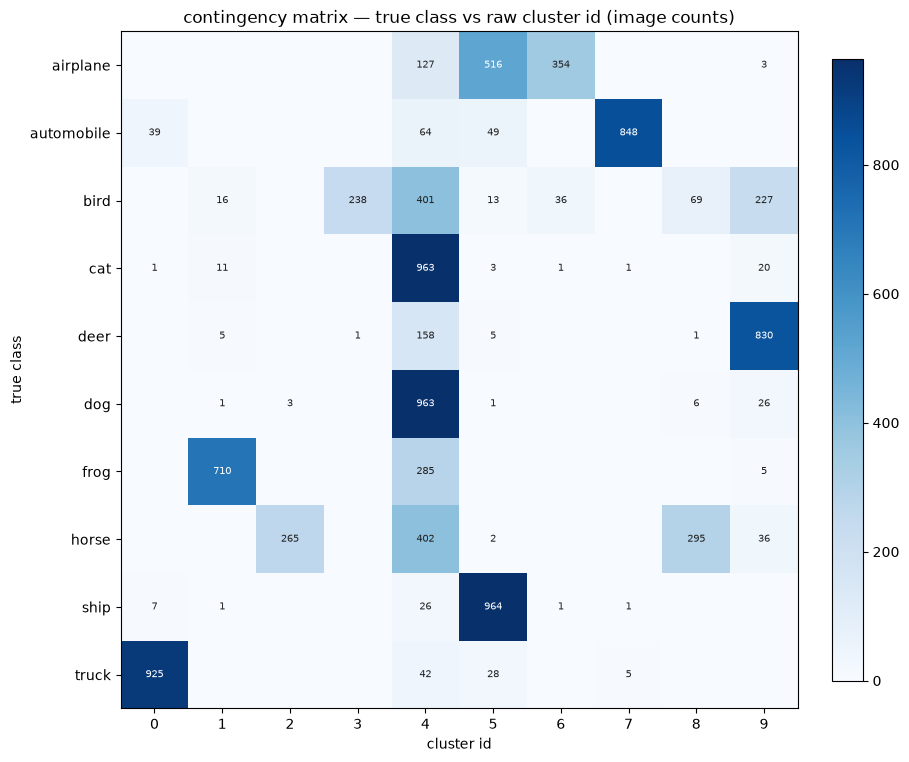

In [9]:
# contingency matrix: true class (rows) vs RAW cluster id 0..9 (cols) — no relabeling at all.
# the most faithful view: shows exactly how each class is split across clusters. a column that
# lights up across many rows is a giant MIXED cluster (the big low-purity blob from above).
from sklearn.metrics import confusion_matrix

cont = confusion_matrix(y_true, cluster_id, labels=range(10))    # [class, cluster] counts

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
im = ax.imshow(cont, cmap="Blues")
ax.set_xticks(range(10)); ax.set_xticklabels(range(10))
ax.set_yticks(range(10)); ax.set_yticklabels(CIFAR10_CLASSES)
ax.set_xlabel("cluster id"); ax.set_ylabel("true class")
ax.set_title("contingency matrix — true class vs raw cluster id (image counts)")
thresh = cont.max() * 0.5
for i in range(10):
    for j in range(10):
        v = int(cont[i, j])
        if v:
            ax.text(j, i, str(v), ha="center", va="center", fontsize=7,
                    color="white" if v > thresh else "#222222")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

clustering accuracy (optimal 1-to-1 assignment): 0.613


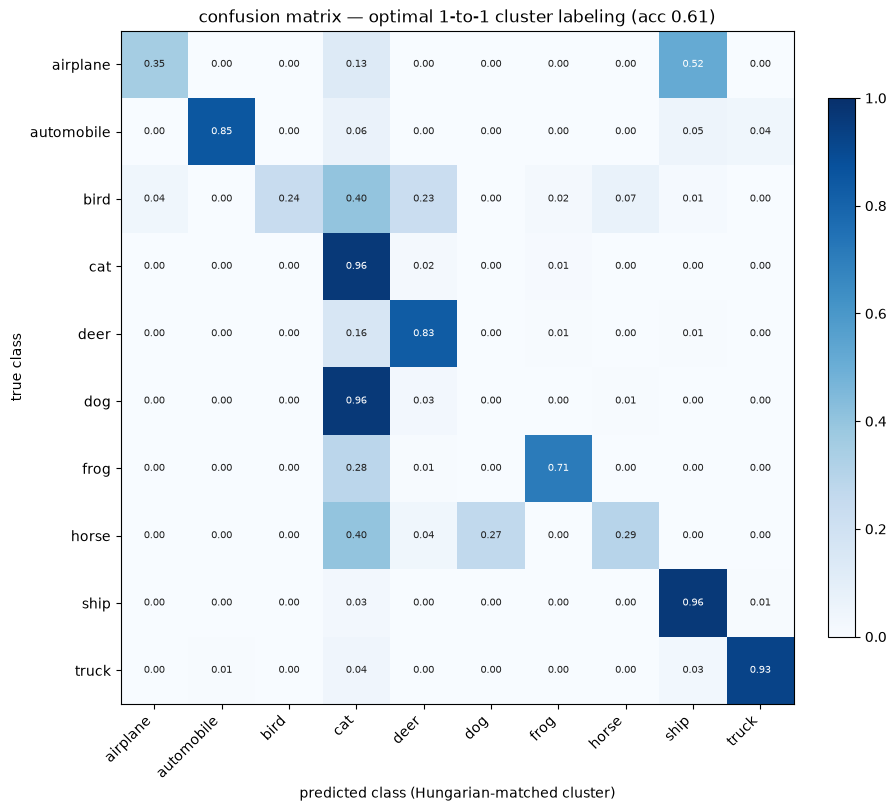

In [10]:
# honest confusion matrix via an OPTIMAL 1-to-1 (Hungarian) cluster->class assignment.
# majority vote (above) lets two clusters claim the same class and leaves other classes
# unclaimed, so the class-vs-class matrix isn't a permutation. linear_sum_assignment picks
# the bijection cluster<->class that maximizes total agreement -> the standard "clustering
# accuracy" (ACC). every class now appears exactly once (no doubled / empty columns).
from scipy.optimize import linear_sum_assignment

w = confusion_matrix(cluster_id, y_true, labels=range(10))      # [cluster, class] counts
row, col = linear_sum_assignment(w, maximize=True)              # each cluster -> a DISTINCT class
opt_map = dict(zip(row, col))
pred_opt = np.array([opt_map[c] for c in cluster_id])
acc = (pred_opt == y_true).mean()
print(f"clustering accuracy (optimal 1-to-1 assignment): {acc:.3f}")

cm = confusion_matrix(y_true, pred_opt, labels=range(10))
cm_norm = cm / cm.sum(axis=1, keepdims=True)                    # row-normalized = recall per true class

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(CIFAR10_CLASSES)
ax.set_xlabel("predicted class (Hungarian-matched cluster)"); ax.set_ylabel("true class")
ax.set_title(f"confusion matrix — optimal 1-to-1 cluster labeling (acc {acc:.2f})")
for i in range(10):
    for j in range(10):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if cm_norm[i, j] > 0.5 else "#222222")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

# K-Means on L2-normalized features

Everything above clustered the **raw** encoder features, where Euclidean distance is dominated
by each vector's *magnitude* (`||f||`) — the class-irrelevant "how loud" the activation is —
which collapsed most classes into one giant mixed cluster.

Here we rerun the exact same pipeline on **L2-normalized** features (`f / ||f||`), placing every
image on the unit sphere. Euclidean distance then reduces to `2 − 2·cos(angle)`, so k-means
clusters on *direction only* — the same cosine geometry the centroid analysis used. Compare the
cluster sizes, the giant-blob column, and the accuracy against the raw run above. All variables
here get an `_n` suffix so the raw results above stay intact.

In [11]:
# L2-normalize each feature vector to unit length, then run the SAME k-means on it.
# division is per-row: X_norm[i] = X[i] / ||X[i]||, so only DIRECTION survives (magnitude -> 1).
X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)   # [N, 512], every row now unit length

kmeans_n = KMeans(n_clusters=10, n_init=10, random_state=0)
cluster_id_n = kmeans_n.fit_predict(X_norm)             # [N] cluster assignment on normalized feats

print("cluster sizes (normalized):", np.bincount(cluster_id_n))
print("inertia:", f"{kmeans_n.inertia_:.1f}")

cluster sizes (normalized): [ 830 1377  310  940  214  819 3391  890  739  490]
inertia: 4291.8


In [12]:
# per-cluster purity on the normalized clustering (same read as the raw purity report above).
cluster_to_class_n = {}
for c in range(10):
    m = cluster_id_n == c
    cluster_to_class_n[c] = int(mode(y_true[m], keepdims=False).mode)

for c in range(10):
    m = cluster_id_n == c
    frac = (y_true[m] == cluster_to_class_n[c]).mean()
    print(f"cluster {c}: size {m.sum():5d}  ->  {CIFAR10_CLASSES[cluster_to_class_n[c]]:<11} ({frac:.0%} pure)")

weighted_purity_n = np.mean([(y_true[cluster_id_n == c] == cluster_to_class_n[c]).mean()
                             for c in cluster_id_n])
print(f"\noverall purity (normalized): {weighted_purity_n:.3f}   (raw was {weighted_purity:.3f})")

cluster 0: size   830  ->  ship        (98% pure)
cluster 1: size  1377  ->  airplane    (32% pure)
cluster 2: size   310  ->  bird        (99% pure)
cluster 3: size   940  ->  deer        (82% pure)
cluster 4: size   214  ->  dog         (97% pure)
cluster 5: size   819  ->  automobile  (99% pure)
cluster 6: size  3391  ->  cat         (23% pure)
cluster 7: size   890  ->  truck       (96% pure)
cluster 8: size   739  ->  frog        (95% pure)
cluster 9: size   490  ->  horse       (97% pure)

overall purity (normalized): 0.615   (raw was 0.639)


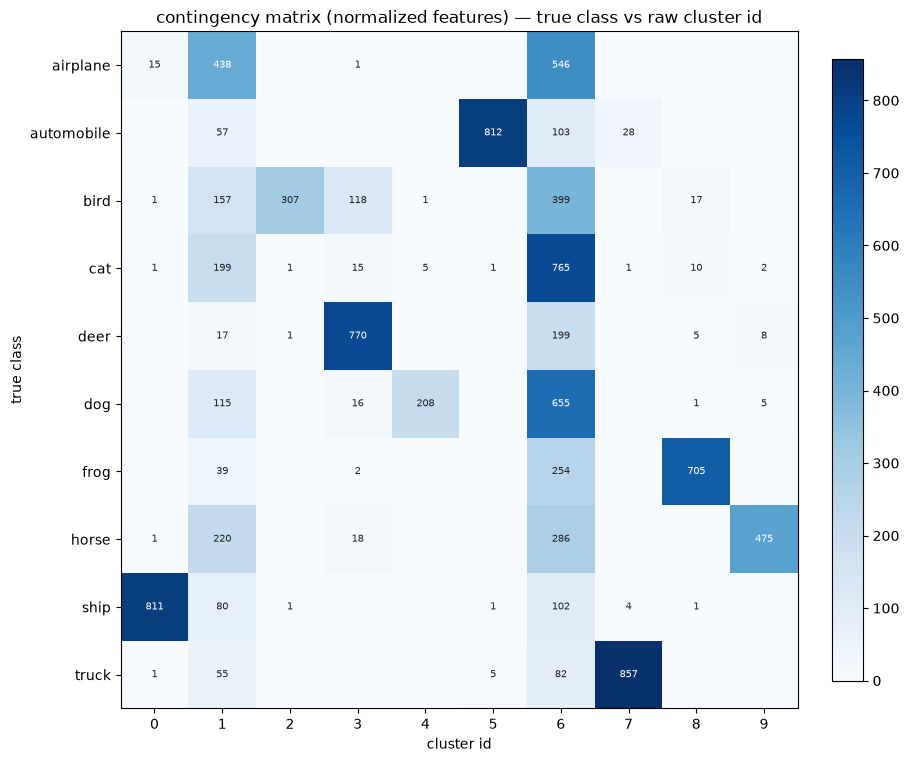

In [13]:
# contingency matrix for the normalized clustering: true class (rows) vs raw cluster id (cols).
# compare to the raw one above — the giant mixed column should be gone / much smaller.
cont_n = confusion_matrix(y_true, cluster_id_n, labels=range(10))    # [class, cluster] counts

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
im = ax.imshow(cont_n, cmap="Blues")
ax.set_xticks(range(10)); ax.set_xticklabels(range(10))
ax.set_yticks(range(10)); ax.set_yticklabels(CIFAR10_CLASSES)
ax.set_xlabel("cluster id"); ax.set_ylabel("true class")
ax.set_title("contingency matrix (normalized features) — true class vs raw cluster id")
thresh = cont_n.max() * 0.5
for i in range(10):
    for j in range(10):
        v = int(cont_n[i, j])
        if v:
            ax.text(j, i, str(v), ha="center", va="center", fontsize=7,
                    color="white" if v > thresh else "#222222")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

clustering accuracy (normalized): 0.615   (raw was 0.613)


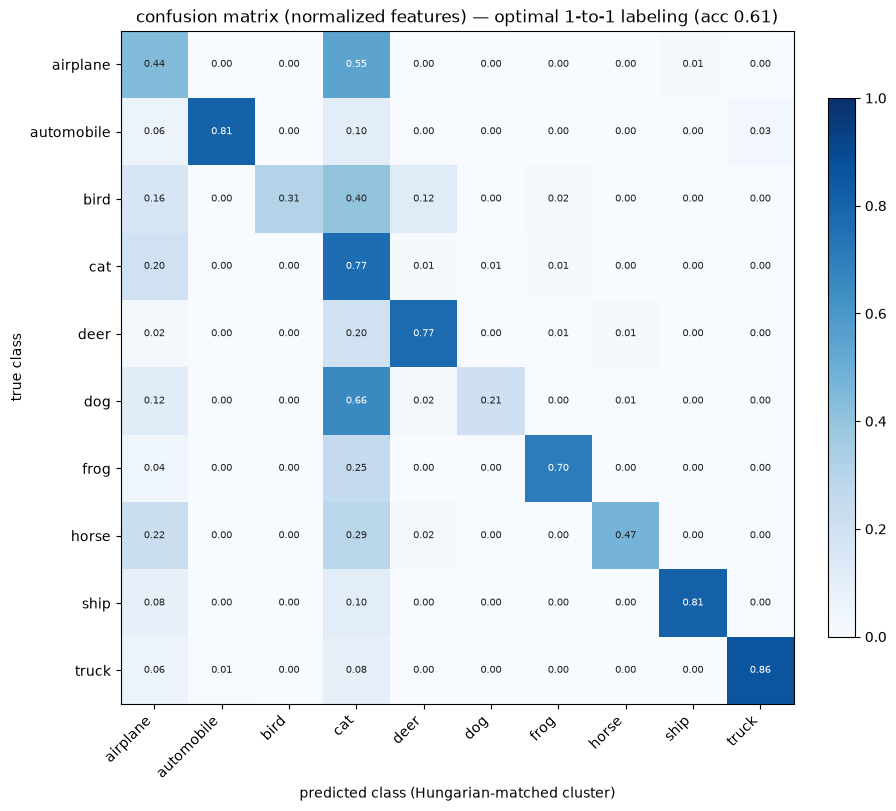

In [14]:
# Hungarian 1-to-1 confusion matrix + clustering accuracy for the NORMALIZED features.
w_n = confusion_matrix(cluster_id_n, y_true, labels=range(10))      # [cluster, class] counts
row_n, col_n = linear_sum_assignment(w_n, maximize=True)           # cluster -> DISTINCT class
opt_map_n = dict(zip(row_n, col_n))
pred_opt_n = np.array([opt_map_n[c] for c in cluster_id_n])
acc_n = (pred_opt_n == y_true).mean()
print(f"clustering accuracy (normalized): {acc_n:.3f}   (raw was {acc:.3f})")

cm_n = confusion_matrix(y_true, pred_opt_n, labels=range(10))
cm_n_norm = cm_n / cm_n.sum(axis=1, keepdims=True)                 # row-normalized = recall per true class

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
im = ax.imshow(cm_n_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(CIFAR10_CLASSES)
ax.set_xlabel("predicted class (Hungarian-matched cluster)"); ax.set_ylabel("true class")
ax.set_title(f"confusion matrix (normalized features) — optimal 1-to-1 labeling (acc {acc_n:.2f})")
for i in range(10):
    for j in range(10):
        ax.text(j, i, f"{cm_n_norm[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if cm_n_norm[i, j] > 0.5 else "#222222")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()